# Übung 6 – Mobilithek: Trends der Pkw-Neuzulassungen 2017–2025 (KBA FZ 4)

Das Notebook `UE6_Mobilithek.ipynb` analysiert den **Querschnitt 2025** im Detail. Hier wechseln
wir die Perspektive auf den **Längsschnitt**: Aus der Mobilithek liegen die FZ-4-Jahresdateien
des Kraftfahrt-Bundesamts für **neun Jahrgänge (2017–2025)** vor – jede davon die komplette
Jahresbilanz der Pkw-Neuzulassungen in Deutschland. Damit lassen sich die großen Bewegungen des
Marktes nachzeichnen: Corona, Halbleiterkrise, Antriebswende, Förder-Stopp.

**Leitfragen**

1. **Gesamtmarkt:** Wie entwickelt sich das Neuzulassungsvolumen über die Jahre – und wie
   teilt es sich dabei in **private und gewerbliche Halter** auf?
2. **Marken:** Welche Hersteller gewinnen, welche verlieren – und wie stabil ist die
   Marktspitze?
3. **Motorisierung:** Wie verlaufen die Trajektorien der einzelnen Antriebsarten – wann
   überholt wer wen?

**Methodischer Rahmen:** Jeder Jahrgang ist eine **Vollerhebung** – die Argumentation aus
Abschnitt 7 des Querschnitt-Notebooks gilt hier unverändert: Signifikanztests hätten keine
sinnvolle Fragestellung, die ehrliche Währung sind **Effektgrößen** (Anteile, Wachstumsraten,
Spannweiten). Die eigentliche methodische Arbeit steckt diesmal im **harmonisierten Einlesen**:
Neun Excel-Dateien aus drei Formatgenerationen müssen auf ein gemeinsames Schema gebracht
werden, ohne dass unterwegs still Zulassungen verloren gehen.

## 1. Setup

Farbsystem wie in Übung 4/5 und im Querschnitt-Notebook (feste, CVD-geprüfte Palette; Farben
werden Entitäten fest zugeordnet – Elektro ist in jeder Grafik grün, Diesel violett).

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")          # openpyxl/xlrd-Stilwarnungen der KBA-Dateien
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)

# ── Farbsystem (wie in Übung 4/5, CVD-geprüft) ───────────────────────────────
SERIES = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
          "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
SURFACE = "#fcfcfb"
INK, INK2 = "#0b0b0b", "#52514e"
GRAU = "#9a9891"

# Feste Farb-Zuordnung nach Antriebsart (identisch zum Querschnitt-Notebook):
COL_FUEL = {"Hybrid": SERIES[0], "Elektro": SERIES[1], "Benzin": SERIES[2],
            "Diesel": SERIES[4], "Gas": SERIES[3], "Wasserstoff": SERIES[6],
            "Übrige": GRAU}
COL_BAR = SERIES[0]

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2,
    "axes.titlesize": 11.5, "axes.titlecolor": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "grid.color": "#e7e6e2", "grid.linewidth": 0.8,
    "legend.frameon": False,
})

def tsd(n):
    return f"{int(n):,}".replace(",", ".")

## 2. Einlesen: neun Jahrgänge, drei Formatgenerationen

Die FZ-4-Dateien sind Präsentations-Excels (vgl. Querschnitt-Notebook, Abschnitt 2). Für den
Längsschnitt kommen **drei Formatgenerationen** dazu, die der Parser abfangen muss:

1. **2017** ist eine `.xls`-Datei (Engine `xlrd`) mit **anderen Blattnamen**
   (`Pkw-Herst-Merkm` / `Pkw-Herst-Typ-Merkm` statt `FZ 4.1` / `FZ 4.2`) – die Spaltenstruktur
   ab Zeile 10 ist aber identisch.
2. **2017–2021** markieren die Zwischensummen je Hersteller als eigene Zeile
   „`<HERSTELLER> ZUSAMMEN`“ **in der Herstellerspalte**; **ab 2022** steht „ZUSAMMEN“ in der
   Handelsnamen-Spalte. Wer nur eine Variante filtert, **verdoppelt** die Jahressumme –
   unser erster Parserlauf lieferte für 2017 genau das: 6,88 statt 3,44 Mio.
3. Die Zeilen `SONSTIGE HERSTELLER` (ohne Typdaten) und die KBA-Symbolik
   (`-` = 0; `.`/`X` = unbekannt) gibt es in allen Jahrgängen.

Aus **FZ 4.1** ziehen wir die Jahressumme je Hersteller **samt der Spalte „private Halter“**,
aus **FZ 4.2** die Modellzeilen mit Kraftstoffart – beides markerbasiert bis zur
`INSGESAMT`-Zeile geschnitten.

In [4]:
DATEIEN = {
    2017: "fz4_2017_xls.xls", 2018: "fz4_2018_xls.xlsx", 2019: "fz4_2019_xlsx.xlsx",
    2020: "fz4_2020.xlsx", 2021: "fz4_2021.xlsx", 2022: "fz4_2022.xlsx",
    2023: "fz4_2023.xlsx", 2024: "fz4_2024.xlsx", 2025: "fz4_2025.xlsx",
}
BLATT = {2017: ("Pkw-Herst-Merkm", "Pkw-Herst-Typ-Merkm")}    # ab 2018: FZ 4.1 / FZ 4.2

def zahlen(s):
    # KBA-Symbolik: '-' = nichts vorhanden (-> 0); '.', '/', 'X' = unbekannt (-> NaN)
    s = s.astype(object).mask(s.astype(str).str.strip().eq("-"), 0)
    return pd.to_numeric(s, errors="coerce")

def lies_jahr(jahr):
    b1, b2 = BLATT.get(jahr, ("FZ 4.1", "FZ 4.2"))
    raw1 = pd.read_excel(DATEIEN[jahr], sheet_name=b1, header=None)
    raw2 = pd.read_excel(DATEIEN[jahr], sheet_name=b2, header=None)

    # FZ 4.1: Hersteller | Schl.-Nr. | Insgesamt | Wohnmobile | private Halter | ...
    h = raw1.iloc[9:, 1:6].copy()
    h.columns = ["Hersteller", "SchlNr", "Insgesamt", "Wohnmobile", "privat"]
    h["Hersteller"] = h["Hersteller"].astype(str).str.strip()
    stop = h.index[h["Hersteller"].eq("INSGESAMT")][0]
    total = int(zahlen(h.loc[[stop], "Insgesamt"]).iloc[0])
    total_privat = int(zahlen(h.loc[[stop], "privat"]).iloc[0])
    h = h.loc[:stop - 1]
    for sp in ("Insgesamt", "privat"):
        h[sp] = zahlen(h[sp])
    h = h[h["Hersteller"].ne("") & h["Hersteller"].ne("nan")].dropna(subset=["Insgesamt"])

    # FZ 4.2: Hersteller | Handelsname | Typ | kW | Kraftstoffart | ... | Insgesamt
    m = raw2.iloc[9:, 1:9].copy()
    m.columns = ["Hersteller", "Handelsname", "Typ", "kW", "Kraftstoff", "Allrad", "Aufbau", "Insgesamt"]
    for sp in ("Hersteller", "Handelsname"):
        m[sp] = m[sp].astype(str).str.strip().replace({"nan": np.nan})
    stop2 = m.index[m["Hersteller"].eq("INSGESAMT") | m["Handelsname"].eq("INSGESAMT")][0]
    m = m.loc[:stop2 - 1]
    # „SONSTIGE HERSTELLER“ (eine Zeile, ab 2022 mit Handelsname „ZUSAMMEN“) vor dem Filtern sichern
    ist_sonst = m["Hersteller"].fillna("").str.contains("SONSTIGE")
    sonstige = int(zahlen(m.loc[ist_sonst, "Insgesamt"]).sum())
    m = m[~ist_sonst]
    m = m[~m["Hersteller"].fillna("").str.contains("ZUSAMMEN")]     # 2017–21: „X ZUSAMMEN“
    m["Hersteller"] = m["Hersteller"].ffill()                        # verbundene Zellen auffüllen
    m = m[~m["Handelsname"].fillna("").str.contains("ZUSAMMEN")]    # ab 2022: eigene Zeile
    m["Insgesamt"] = zahlen(m["Insgesamt"])
    m = m.dropna(subset=["Insgesamt"])
    m["Kraftstoff"] = m["Kraftstoff"].astype(str).str.strip()
    return h, m, total, total_privat, sonstige

JAHRE = sorted(DATEIEN)
HERSTELLER, MODELLE, GESAMT, PRIVAT, SONSTIGE = {}, {}, {}, {}, {}
for j in JAHRE:
    HERSTELLER[j], MODELLE[j], GESAMT[j], PRIVAT[j], SONSTIGE[j] = lies_jahr(j)

gesamt = pd.Series(GESAMT, name="Neuzulassungen")
privat = pd.Series(PRIVAT, name="privat")
print(pd.DataFrame({"Neuzulassungen": gesamt.map(tsd),
                    "Hersteller in FZ 4.1": [len(HERSTELLER[j]) for j in JAHRE],
                    "Modellzeilen in FZ 4.2": [len(MODELLE[j]) for j in JAHRE]},
                   index=JAHRE).to_string())

     Neuzulassungen  Hersteller in FZ 4.1  Modellzeilen in FZ 4.2
2017      3.441.262                    59                    3268
2018      3.435.778                    64                    3227
2019      3.607.258                    60                    3204
2020      2.917.678                    62                    3250
2021      2.622.132                    67                    2896
2022      2.651.357                    71                    2490
2023      2.844.609                    74                    2512
2024      2.817.331                    77                    2764
2025      2.857.591                    78                    2453


## 3. Datenqualität: Kontrollsummen über alle Jahrgänge

Wie im Querschnitt prüfen wir gegen die mitgelieferten KBA-Kontrollsummen – diesmal für jeden
Jahrgang: Summe aller Herstellerzeilen (FZ 4.1, insgesamt und privat) und Summe aller
Modellzeilen plus `SONSTIGE HERSTELLER` (FZ 4.2) müssen jeweils exakt die `INSGESAMT`-Zeile
treffen. Das ist zugleich der Regressionstest für die drei Formatgenerationen des Parsers.

In [5]:
kontrolle = pd.DataFrame({
    "INSGESAMT laut KBA": [tsd(GESAMT[j]) for j in JAHRE],
    "Δ Σ FZ 4.1": [int(HERSTELLER[j]["Insgesamt"].sum()) - GESAMT[j] for j in JAHRE],
    "Δ Σ privat FZ 4.1": [int(HERSTELLER[j]["privat"].sum()) - PRIVAT[j] for j in JAHRE],
    "Δ Σ FZ 4.2 + Sonstige": [int(MODELLE[j]["Insgesamt"].sum()) + SONSTIGE[j] - GESAMT[j]
                              for j in JAHRE],
}, index=JAHRE)
pruef = ["Δ Σ FZ 4.1", "Δ Σ privat FZ 4.1", "Δ Σ FZ 4.2 + Sonstige"]
kontrolle["ok"] = np.where(kontrolle[pruef].eq(0).all(axis=1), "✓", "✗")
print(kontrolle.to_string())
assert (kontrolle["ok"] == "✓").all()

     INSGESAMT laut KBA  Δ Σ FZ 4.1  Δ Σ privat FZ 4.1  Δ Σ FZ 4.2 + Sonstige ok
2017          3.441.262           0                  0                      0  ✓
2018          3.435.778           0                  0                      0  ✓
2019          3.607.258           0                  0                      0  ✓
2020          2.917.678           0                  0                      0  ✓
2021          2.622.132           0                  0                      0  ✓
2022          2.651.357           0                  0                      0  ✓
2023          2.844.609           0                  0                      0  ✓
2024          2.817.331           0                  0                      0  ✓
2025          2.857.591           0                  0                      0  ✓


## 4. Gesamtmarkt: Volumen, privat und gewerblich (Leitfrage 1)

FZ 4.1 weist je Hersteller die **privaten Halter** separat aus; alles andere – Firmenwagen,
Leasing- und Vermietflotten, Händler- und Hersteller-Eigenzulassungen – ist **gewerblich**
(= Insgesamt − privat). Wichtig beim Lesen: Privat-Leasing läuft über den gewerblichen Halter
(die Leasinggesellschaft), der Privatanteil ist also eher eine **Untergrenze** für die private
Nachfrage.

Als konjunkturellen Maßstab legen wir zusätzlich das **Bruttoinlandsprodukt** daneben
(Statista auf Basis Destatis; **nominal**, d. h. in jeweiligen Preisen): Läuft der Automarkt
einfach mit der Gesamtwirtschaft – oder hat er sich von ihr gelöst? Da Mrd. Euro und
Tsd. Zulassungen nicht auf eine gemeinsame Achse gehören (und Doppelachsen tabu sind), zeigt
das rechte Panel beide Größen **indexiert auf 2017 = 100**.

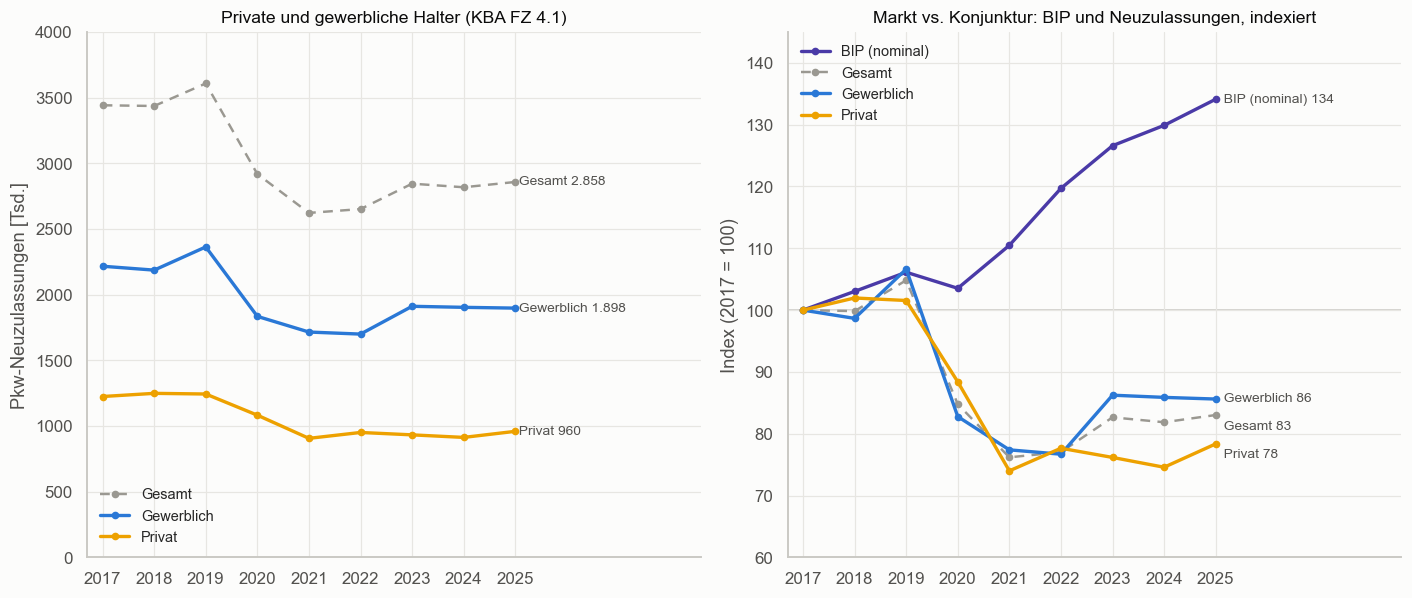

         Gesamt     Privat Gewerblich  Privatanteil [%]  BIP nominal [Mrd. €]
2017  3.441.262  1.224.943  2.216.319              35.6                3333.1
2018  3.435.778  1.249.011  2.186.767              36.4                3434.0
2019  3.607.258  1.244.002  2.363.256              34.5                3537.3
2020  2.917.678  1.082.899  1.834.779              37.1                3450.7
2021  2.622.132    906.588  1.715.544              34.6                3682.3
2022  2.651.357    951.366  1.699.991              35.9                3989.4
2023  2.844.609    933.147  1.911.462              32.8                4219.3
2024  2.817.331    913.722  1.903.609              32.4                4329.0
2025  2.857.591    959.967  1.897.624              33.6                4469.9


In [6]:
# BIP als Konjunktur-Referenz (Statista id14397, Basis Destatis; nominal, Mrd. Euro)
bip = pd.read_excel("statistic_id14397_bruttoinlandsprodukt--bip--in-deutschland-1970-2025.xlsx",
                    sheet_name="Daten", header=None, skiprows=5, usecols=[1, 2],
                    names=["Jahr", "BIP"]).set_index("Jahr")["BIP"].sort_index().loc[JAHRE]

halter = pd.DataFrame({"Gesamt": gesamt, "Privat": privat,
                       "Gewerblich": gesamt - privat})
COL_HALTER = {"Gesamt": GRAU, "Gewerblich": SERIES[0], "Privat": SERIES[2],
              "BIP (nominal)": SERIES[4]}

# indexiert auf 2017 = 100: einzige saubere gemeinsame Achse für Mrd. € und Tsd. Pkw
index = pd.concat([halter[["Gesamt", "Gewerblich", "Privat"]],
                   bip.rename("BIP (nominal)")], axis=1)
index = index / index.loc[2017] * 100

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5.6))

# links: absolute Volumina
for sp in ["Gesamt", "Gewerblich", "Privat"]:
    stil = dict(dashes=(4, 3), lw=1.6) if sp == "Gesamt" else dict(lw=2.2)
    ax.plot(JAHRE, halter[sp] / 1000, color=COL_HALTER[sp], marker="o", ms=4,
            label=sp, **stil)
    ax.annotate(f" {sp} {halter.loc[2025, sp]/1000:,.0f}".replace(",", "."),
                (JAHRE[-1], halter.loc[2025, sp] / 1000), fontsize=9, color=INK2,
                va="center")
ax.set_xticks(JAHRE)
ax.set_xlim(2016.7, 2028.6)
ax.set_ylim(0, 4000)
ax.set_ylabel("Pkw-Neuzulassungen [Tsd.]")
ax.set_title("Private und gewerbliche Halter (KBA FZ 4.1)")
ax.legend(loc="lower left", fontsize=9.5)

# rechts: Markt vs. Konjunktur, indexiert (Endwert-Labels bei Bedarf auseinandergeschoben)
beschriftung = []
for sp in ["BIP (nominal)", "Gesamt", "Gewerblich", "Privat"]:
    stil = dict(dashes=(4, 3), lw=1.6) if sp == "Gesamt" else dict(lw=2.2)
    ax2.plot(JAHRE, index[sp], color=COL_HALTER[sp], marker="o", ms=4, label=sp, **stil)
    beschriftung.append([index.loc[2025, sp], f"{sp} {index.loc[2025, sp]:.0f}"])
ax2.axhline(100, color="#c9c8c3", lw=1, zorder=0)
beschriftung.sort(reverse=True)
vorher = np.inf
for y0, text in beschriftung:
    y_lbl = min(y0, vorher - 4.5)
    vorher = y_lbl
    ax2.annotate(f"  {text}", (JAHRE[-1], y_lbl), fontsize=9, color=INK2, va="center")
ax2.set_xticks(JAHRE)
ax2.set_xlim(2016.7, 2028.6)
ax2.set_ylim(60, 145)
ax2.set_ylabel("Index (2017 = 100)")
ax2.set_title("Markt vs. Konjunktur: BIP und Neuzulassungen, indexiert")
ax2.legend(loc="upper left", fontsize=9.5)
plt.tight_layout()
plt.show()

halter["Privatanteil [%]"] = (halter["Privat"] / halter["Gesamt"] * 100).round(1)
halter["BIP nominal [Mrd. €]"] = bip.round(1)
print(halter.assign(**{sp: halter[sp].map(tsd) for sp in
                       ["Gesamt", "Privat", "Gewerblich"]}).to_string())

## 5. Marken: Gewinner und Verlierer (Leitfrage 2)

Für den Markenvergleich müssen die Herstellerschlüssel **harmonisiert** werden (Abschnitt 3):
Die heutigen Stellantis-Schlüssel (Opel, Peugeot, Citroën, FCA, PSA, Stellantis) fassen wir als
**Stellantis-Verbund** zusammen, Toyota Europe + Toyota (J) als Toyota, Renault + Ampere als
Renault, die drei Hyundai-Werksschlüssel als Hyundai. Gezeigt werden die **acht kumuliert
größten Marken** in einem gemeinsamen Liniendiagramm – mehr Linien trägt eine einzelne Grafik
nicht, ohne unlesbar zu werden; jede Marke behält ihre feste Farbe, die Veränderung 2025
gegenüber 2017 steht an der Linie. Die Ränge 9 ff. (Renault, Hyundai, Toyota, Tesla, …) zeigt
die Marktanteilstabelle unter der Grafik.

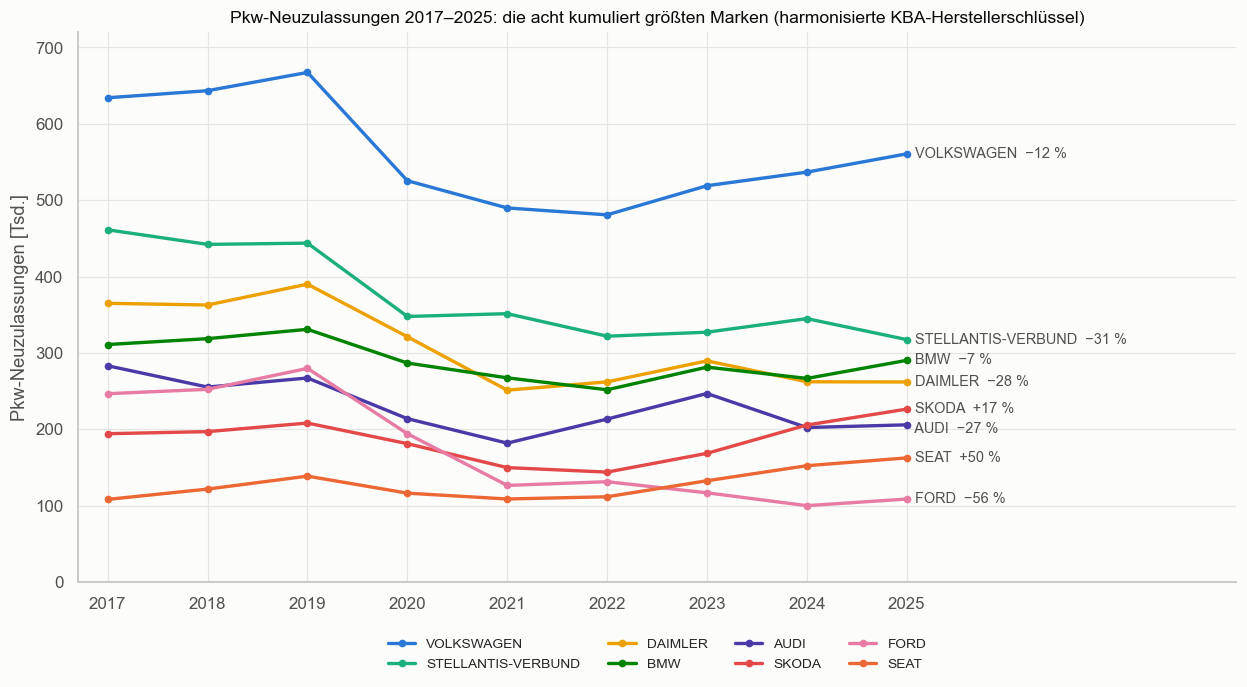

Marktanteile [%]:
                    2017  2019  2021  2023  2025
Hersteller                                      
VOLKSWAGEN          18.4  18.5  18.7  18.2  19.6
STELLANTIS-VERBUND  13.4  12.3  13.4  11.5  11.1
DAIMLER             10.6  10.8   9.6  10.2   9.2
BMW                  9.0   9.2  10.2   9.9  10.2
AUDI                 8.2   7.4   6.9   8.7   7.2
SKODA                5.6   5.8   5.7   5.9   7.9
FORD                 7.2   7.8   4.8   4.1   3.8
SEAT                 3.1   3.8   4.1   4.7   5.7
RENAULT              4.0   4.5   4.6   3.2   2.5
HYUNDAI              3.2   3.6   4.1   3.7   3.3
TOYOTA               2.4   2.4   2.9   2.8   3.2
TESLA                0.1   0.3   1.5   2.2   0.7


In [7]:
STELLANTIS = {"OPEL", "PEUGEOT (F)", "CITROEN (F)", "FCA (I)", "PSA AUTOMOBILES (F)",
              "STELLANTIS (F)", "STELLANTIS (I)"}

def marke(name):
    if name in STELLANTIS:
        return "STELLANTIS-VERBUND"
    if name in ("RENAULT (F)", "AMPERE (F)"):
        return "RENAULT"
    if name.startswith(("TOYOTA", "HYUNDAI", "KIA")):
        return name.split(" ")[0].split(" (")[0]
    return name.split(" (")[0]

marken = pd.DataFrame({j: HERSTELLER[j].groupby(HERSTELLER[j]["Hersteller"].map(marke))
                          ["Insgesamt"].sum() for j in JAHRE}).fillna(0).astype(int)
top = marken.sum(axis=1).sort_values(ascending=False)
auswahl = top.head(8).index.tolist()
COL_MARKE = dict(zip(auswahl, SERIES))          # feste Farbe je Marke, nie umsortieren

fig, ax = plt.subplots(figsize=(11.5, 6.4))
beschriftung = []
for name in auswahl:
    y = marken.loc[name, JAHRE] / 1000
    ax.plot(JAHRE, y, color=COL_MARKE[name], lw=2.2, marker="o", ms=4, label=name)
    vorz = f"{(y.iloc[-1] / y.iloc[0] - 1) * 100:+.0f}".replace("-", "−")
    beschriftung.append([y.iloc[-1], f"{name}  {vorz} %", COL_MARKE[name]])
# Direktbeschriftung am rechten Rand, bei Bedarf vertikal auseinandergeschoben
beschriftung.sort(reverse=True)
vorher = np.inf
for y0, text, farbe in beschriftung:
    y_lbl = min(y0, vorher - 26)
    vorher = y_lbl
    ax.annotate(f"  {text}", (JAHRE[-1], y_lbl), fontsize=9.5, color=INK2, va="center")
ax.set_xticks(JAHRE)
ax.set_xlim(2016.7, 2028.3)
ax.set_ylim(0, 720)
ax.set_ylabel("Pkw-Neuzulassungen [Tsd.]")
ax.set_title("Pkw-Neuzulassungen 2017–2025: die acht kumuliert größten Marken "
             "(harmonisierte KBA-Herstellerschlüssel)")
ax.legend(loc="upper center", ncols=4, fontsize=9, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

anteil = marken.loc[top.head(11).index.tolist() + ["TESLA"]].div(pd.Series(GESAMT), axis=1) * 100
print("Marktanteile [%]:")
print(anteil[[2017, 2019, 2021, 2023, 2025]].round(1).to_string())

## 6. Motorisierung: die Trajektorien der Antriebsarten (Leitfrage 3)

Die Modellzeilen aus FZ 4.2, aggregiert nach Kraftstoffart, als Linien je Antriebsart – links
absolut, rechts als Marktanteil. So werden die Überholmanöver sichtbar. Gas (< 0,7 %),
Wasserstoff (< 800 Stück/Jahr) und die nicht getypten Fahrzeuge (1–2 %, Abschnitt 3) sind der
Lesbarkeit halber weggelassen.

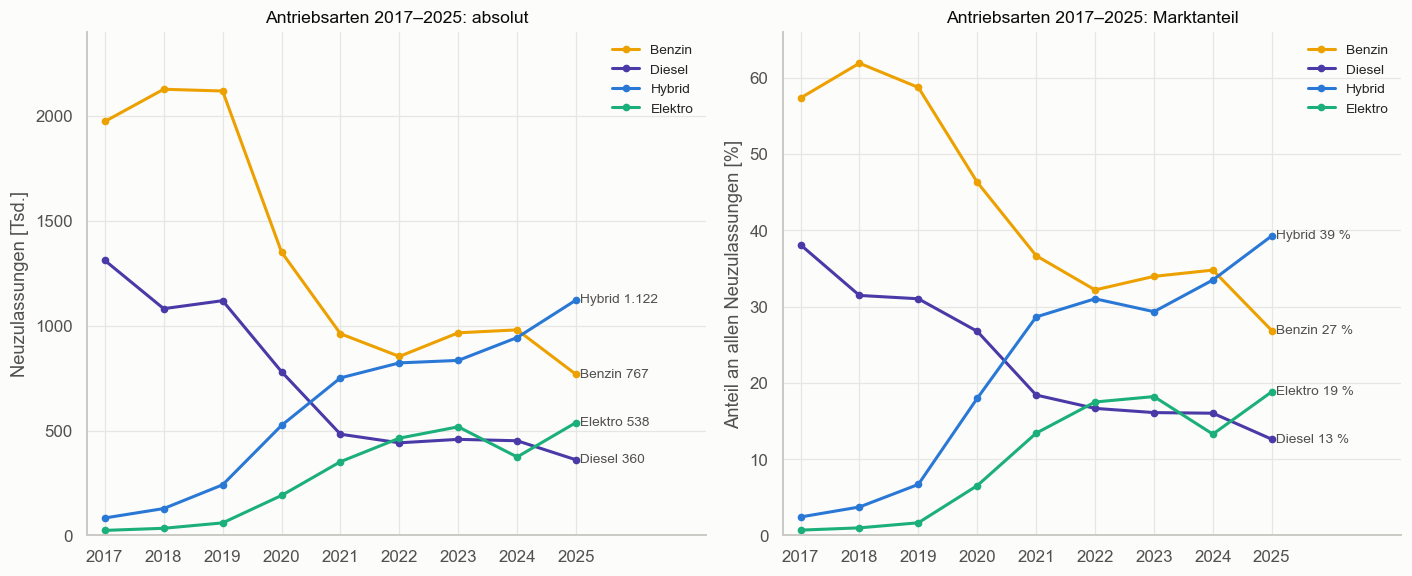

Elektro-Zulassungen je Jahr: {2017: '24.237', 2018: '34.317', 2019: '60.052', 2020: '190.674', 2021: '351.516', 2022: '463.754', 2023: '517.783', 2024: '374.106', 2025: '538.177'}


In [8]:
KRAFTSTOFF = {"B": "Benzin", "D": "Diesel", "E": "Elektro", "H": "Hybrid",
              "G": "Gas", "S": "Wasserstoff"}
antrieb = pd.DataFrame({
    j: MODELLE[j].groupby(MODELLE[j]["Kraftstoff"].map(KRAFTSTOFF))["Insgesamt"].sum()
    for j in JAHRE
}).T.fillna(0).astype(int)

LINIEN = ["Benzin", "Diesel", "Hybrid", "Elektro"]
anteile = antrieb.div(gesamt, axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.4))
for a in LINIEN:
    ax1.plot(JAHRE, antrieb[a] / 1000, color=COL_FUEL[a], lw=2, marker="o", ms=4, label=a)
    ax2.plot(JAHRE, anteile[a], color=COL_FUEL[a], lw=2, marker="o", ms=4, label=a)
    ax1.annotate(f" {a} {antrieb.loc[2025, a]/1000:,.0f}".replace(",", "."),
                 (JAHRE[-1], antrieb.loc[2025, a] / 1000), fontsize=9, color=INK2, va="center")
    ax2.annotate(f" {a} {anteile.loc[2025, a]:.0f} %",
                 (JAHRE[-1], anteile.loc[2025, a]), fontsize=9, color=INK2, va="center")
for ax, ylab, titel in [(ax1, "Neuzulassungen [Tsd.]", "absolut"),
                        (ax2, "Anteil an allen Neuzulassungen [%]", "Marktanteil")]:
    ax.set_xticks(JAHRE)
    ax.set_xlim(2016.7, 2027.2)
    ax.set_ylabel(ylab)
    ax.set_title(f"Antriebsarten 2017–2025: {titel}")
    ax.legend(loc="upper right", fontsize=9)
ax1.set_ylim(0, 2400)
ax2.set_ylim(0, 66)
plt.tight_layout()
plt.show()

print("Elektro-Zulassungen je Jahr:", {j: tsd(antrieb.loc[j, "Elektro"]) for j in JAHRE})